### Xử lý dữ liệu

In [1]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg19
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
import cv2
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm
import segmentation_models_pytorch as smp

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Preprocessing

Sau khi xem qua dữ liệu một lượt, thấy rằng có nhiều vật cản để xác định và tìm ra được hắc tố có thể kể đến như: tóc, lông, vết đo, bị tối,.... 
Áp dụng thuật toán Dullrazor gồm các bước xử lý ảnh truyền thống để "loại bỏ vật cản" đối với việc phân đoạn:
1. Chuyển ảnh sang ảnh xám, từ đó dễ dàng xác định hơn
2. Blackhat morphology làm đối tượng (tóc) nổi lên trong nền
3. Ngưỡng với pixel > 10 sẽ chuyển thành trắng, còn lại là đen
4. Xử dụng thông tin từ 6 pixel xung quanh để điền vào mark được đánh dấu từ bước 3
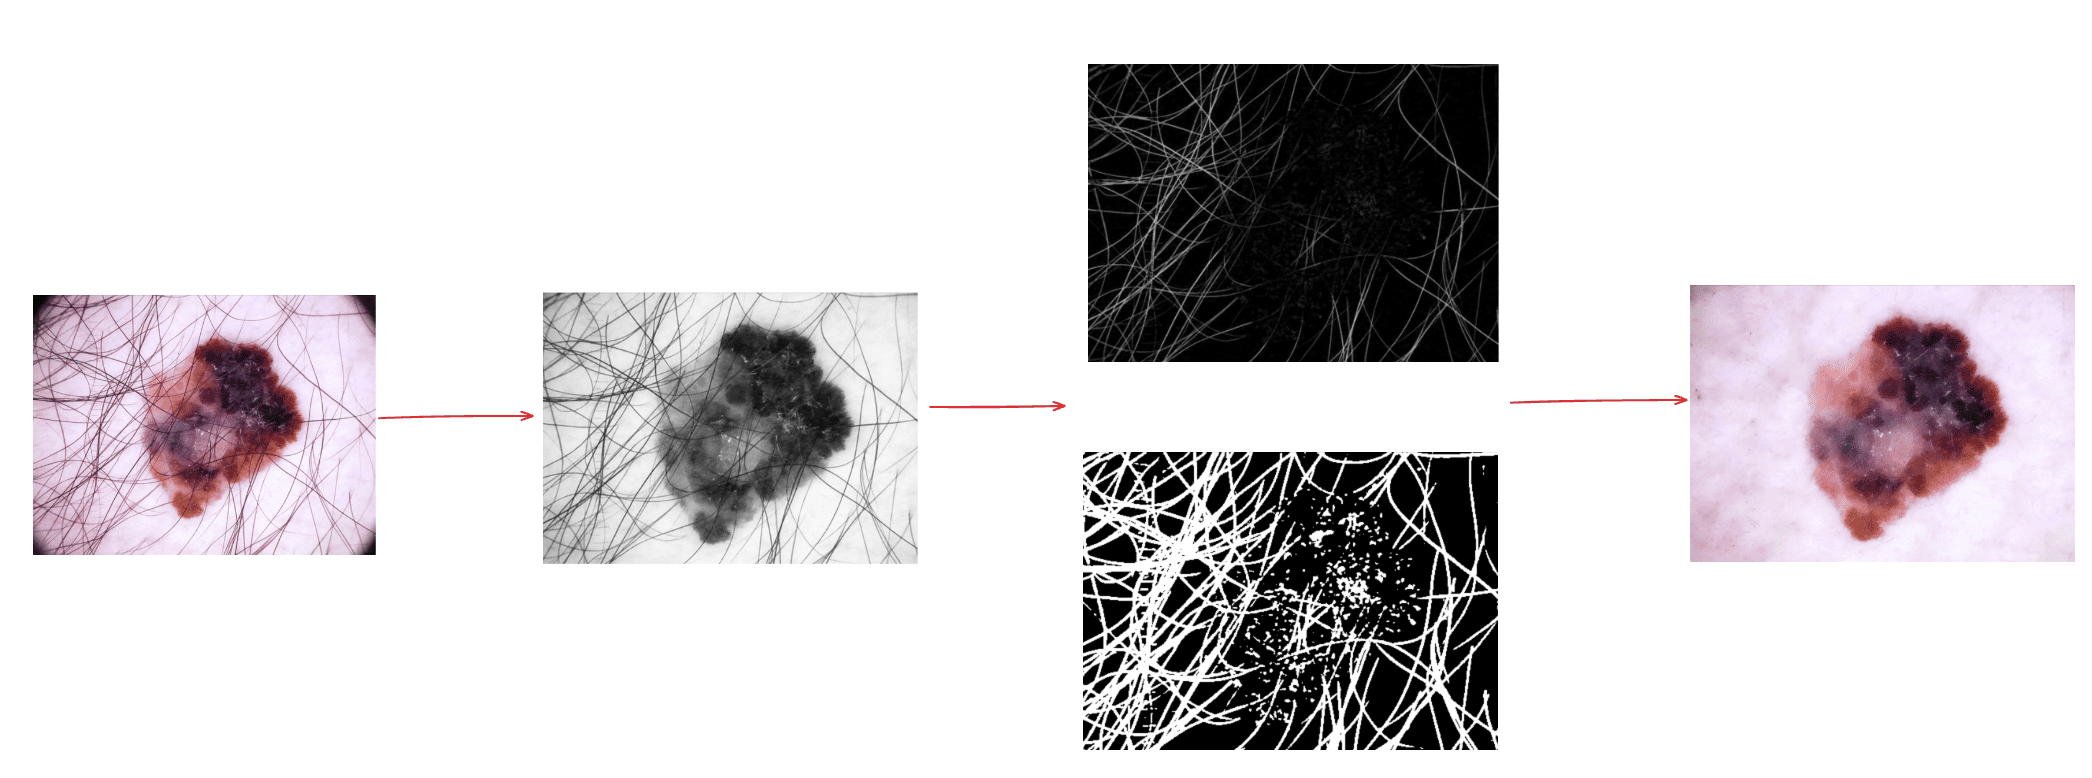
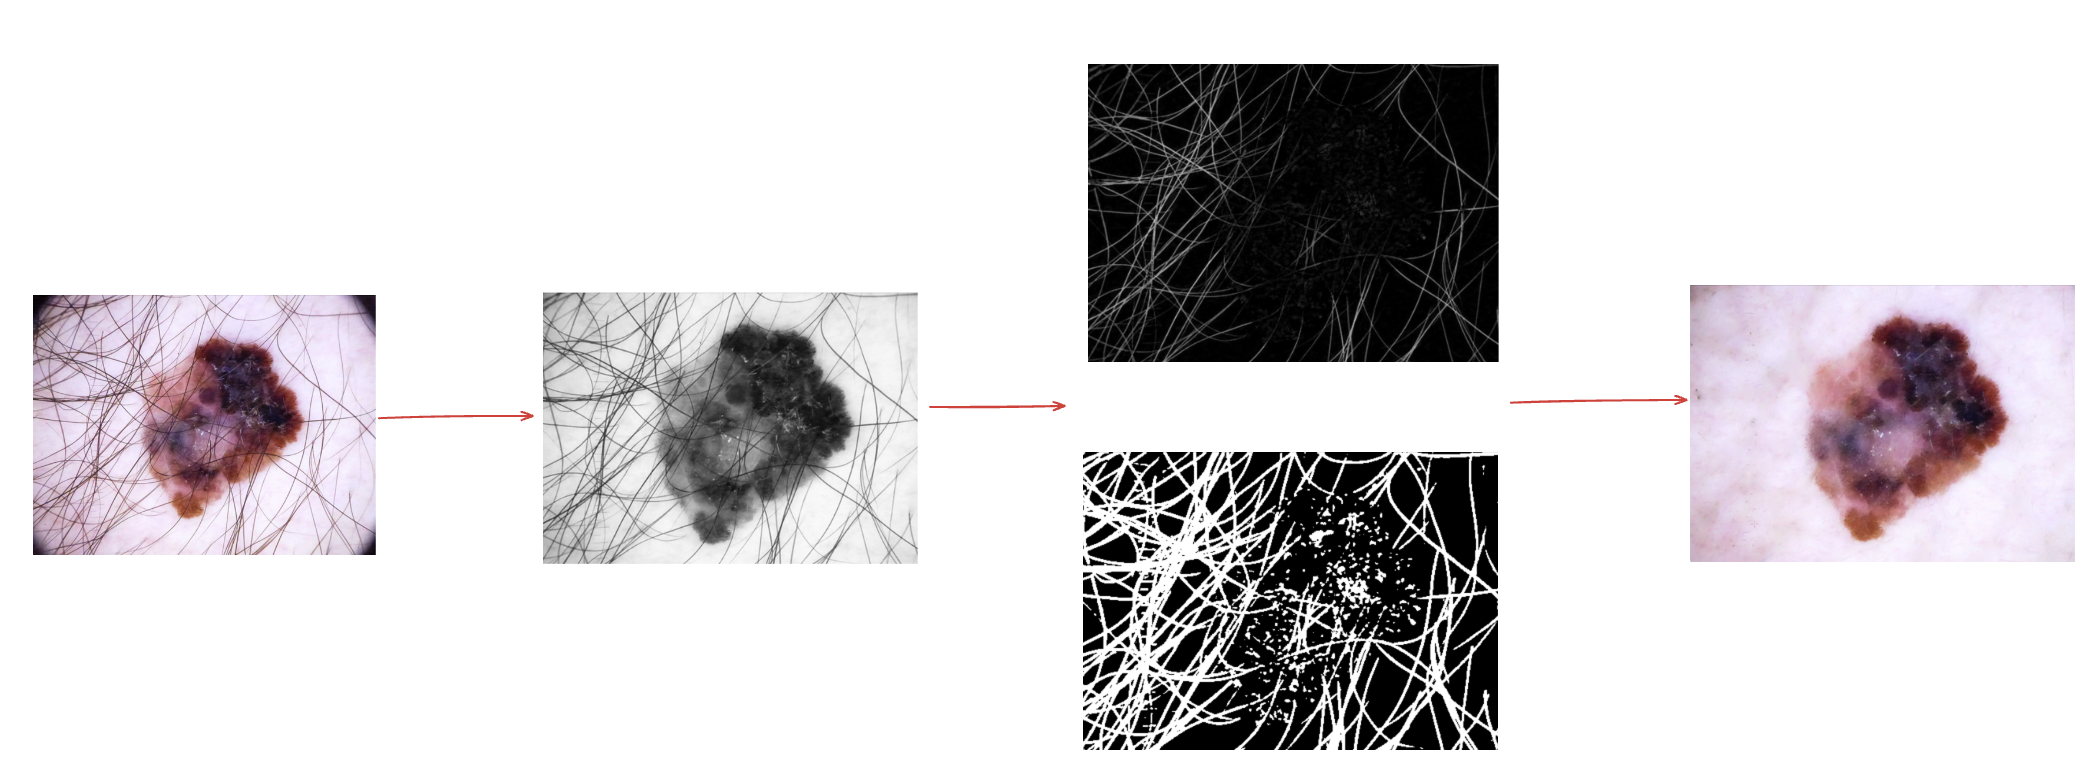

In [3]:
class SkinLesionDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, index):
        image = cv2.imread(self.images[index])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(self.masks[index], cv2.IMREAD_GRAYSCALE)
        mask = mask / 255.0
        
        image = self.remove_artifacts(image)
        
        if self.transform:
            agumented = self.transform(image=image, mask=mask)
            image = agumented["image"]
            mask = agumented["mask"]
    
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        
        return image, mask
        
    def remove_artifacts(self, image):
        #Gray scale
        grayScale = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY )
        #Black hat filter
        kernel = cv2.getStructuringElement(1, (9,9)) 
        # kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
        blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
        #Gaussian filter
        bhg = cv2.GaussianBlur(blackhat, (3,3), cv2.BORDER_DEFAULT)
        #Binary thresholding (MASK)
        _, mask = cv2.threshold(bhg, 10, 255, cv2.THRESH_BINARY)
        #Replace pixels of the mask
        reuslt = cv2.inpaint(image, mask, 6, cv2.INPAINT_TELEA)   
        return reuslt

# Model

Với hiểu biết vốn ban đầu của em về phân đoạn ảnh y tế, mô hình có thể thực hiện tác vụ này là U-net. Nhưng để có hiệu quả tốt nhất em có tham khảo về bài toán đang thực hiện [Paper with code](https://paperswithcode.com/task/lesion-segmentation) và quyết định chọn DoubleUnet làm điểm khởi đầu 

Kiến trúc: 

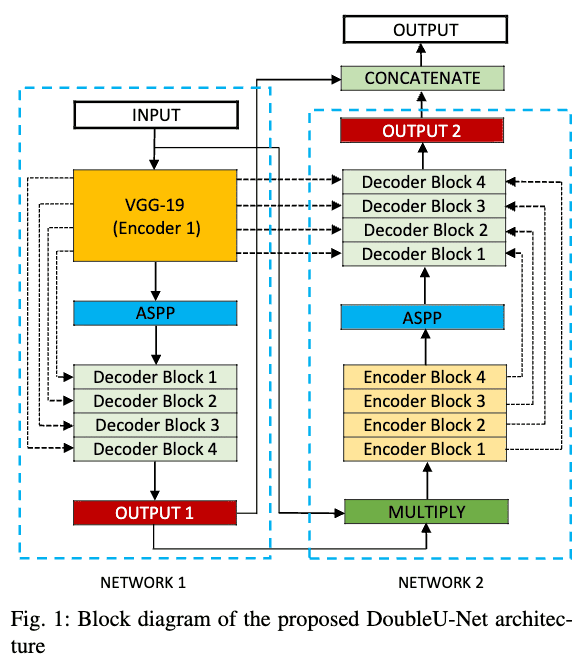
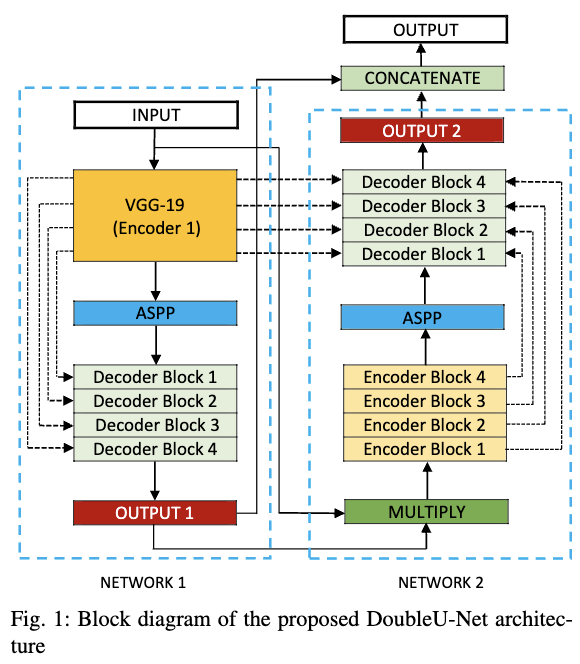
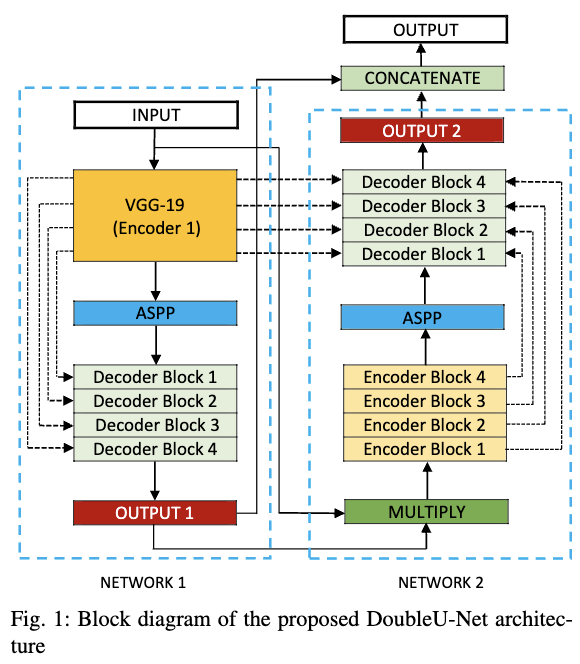

In [4]:
class Conv2D(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, padding=1, dilation=1, bias=False, act=True):
        super().__init__()
        self.act = act

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_c, out_c,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=bias
            ),
            nn.BatchNorm2d(out_c)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        if self.act == True:
            x = self.relu(x)
        return x

class squeeze_excitation_block(nn.Module):
    def __init__(self, in_channels, ratio=8, use_spatial=True):
        super().__init__()

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, max(in_channels//ratio, 8)),
            nn.ReLU(inplace=True),
            nn.Linear(max(in_channels//ratio, 8), in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channel_size, _, _ = x.size()
        y = self.avgpool(x).view(batch_size, channel_size)
        y = self.fc(y).view(batch_size, channel_size, 1, 1)
        return x * y.expand_as(x)

class ASPP(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.avgpool = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            Conv2D(in_c, out_c, kernel_size=1, padding=0)
        )

        self.c1 = Conv2D(in_c, out_c, kernel_size=1, padding=0, dilation=1)
        self.c2 = Conv2D(in_c, out_c, kernel_size=3, padding=6, dilation=6)
        self.c3 = Conv2D(in_c, out_c, kernel_size=3, padding=12, dilation=12)
        self.c4 = Conv2D(in_c, out_c, kernel_size=3, padding=18, dilation=18)

        self.c5 = Conv2D(out_c*5, out_c, kernel_size=1, padding=0, dilation=1)

    def forward(self, x):
        x0 = self.avgpool(x)
        x0 = F.interpolate(x0, size=x.size()[2:], mode="bilinear", align_corners=True)

        x1 = self.c1(x)
        x2 = self.c2(x)
        x3 = self.c3(x)
        x4 = self.c4(x)

        xc = torch.cat([x0, x1, x2, x3, x4], axis=1)
        y = self.c5(xc)
        return y

class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.c1 = Conv2D(in_c, out_c)
        self.c2 = Conv2D(out_c, out_c)
        self.a1 = squeeze_excitation_block(out_c)

    def forward(self, x):
        x = self.c1(x)
        x = self.c2(x)
        x = self.a1(x)
        return x

class encoder1(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # smp efficientnet
        self.encoder = smp.encoders.get_encoder(name="efficientnet-b7", in_channels=3, depth=5, weights="imagenet" if pretrained else None)

        encoder_channels = self.encoder.out_channels[1:]
        
        # self.x1 = vgg.features[:4]   # 64 channels
        # self.x2 = vgg.features[4:9]  # 128 channels  
        # self.x3 = vgg.features[9:18] # 256 channels
        # self.x4 = vgg.features[18:27] # 512 channels
        # self.x5 = vgg.features[27:36] # 512 channels

        self.adapt1 = Conv2D(encoder_channels[0], 64, kernel_size=1, padding=0) # 48 -> 64 ?
        self.adapt2 = Conv2D(encoder_channels[1], 128, kernel_size=1, padding=0) # 32 -> 128
        self.adapt3 = Conv2D(encoder_channels[2], 256, kernel_size=1, padding=0) # 56 -> 256
        self.adapt4 = Conv2D(encoder_channels[3], 512, kernel_size=1, padding=0) # 160 -> 512
        self.adapt5 = Conv2D(encoder_channels[4], 512, kernel_size=1, padding=0) # 448 -> 512 ????

    def forward(self, x):
        features = self.encoder(x)
        # for i, feat in enumerate(features):
        #     print(f"features[{i}].shape = {feat.shape}")
        # Skip feature at index 0
        x1 = self.adapt1(features[1]) # Dimemsion transform like above
        x2 = self.adapt2(features[2])
        x3 = self.adapt3(features[3])
        x4 = self.adapt4(features[4])
        x5 = self.adapt5(features[5])
        
        return x5, [x4, x3, x2, x1]

class decoder1(nn.Module):
    def __init__(self):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.c1 = conv_block(64+512, 256)   # 64 from ASPP + 512 from skip x4  
        self.c2 = conv_block(256+256, 128)  # 256 from c1 + 256 from skip x3
        self.c3 = conv_block(128+128, 64)   # 128 from c2 + 128 from skip x2
        self.c4 = conv_block(64+64, 32)     # 64 from c3 + 64 from skip x1

    def forward(self, x, skip):
        s1, s2, s3, s4 = skip  # [x4, x3, x2, x1] = [512, 256, 128, 64]

        x = self.up(x)
        if x.shape[-2:] != s1.shape[-2:]:
            x = F.interpolate(x, size=s1.shape[-2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, s1], axis=1)  # 64 + 512 = 576
        x = self.c1(x)

        x = self.up(x)
        if x.shape[-2:] != s2.shape[-2:]:
            x = F.interpolate(x, size=s2.shape[-2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, s2], axis=1)  # 256 + 256 = 512
        x = self.c2(x)

        x = self.up(x)
        if x.shape[-2:] != s3.shape[-2:]:
            x = F.interpolate(x, size=s3.shape[-2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, s3], axis=1)  # 128 + 128 = 256
        x = self.c3(x)

        x = self.up(x)
        if x.shape[-2:] != s4.shape[-2:]:
            x = F.interpolate(x, size=s4.shape[-2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, s4], axis=1)  # 64 + 64 = 128
        x = self.c4(x)

        return x

class encoder2(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d((2, 2))

        self.c1 = conv_block(3, 32)
        self.c2 = conv_block(32, 64)
        self.c3 = conv_block(64, 128)
        self.c4 = conv_block(128, 256)

    def forward(self, x):
        x1 = self.c1(x)
        p1 = self.pool(x1)

        x2 = self.c2(p1)
        p2 = self.pool(x2)

        x3 = self.c3(p2)
        p3 = self.pool(x3)

        x4 = self.c4(p3)
        p4 = self.pool(x4)

        return p4, [x4, x3, x2, x1]

class decoder2(nn.Module):
    def __init__(self):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.c1 = conv_block(64+512+256, 256)   # 64 from ASPP2 + 512 from encoder1 + 256 from encoder2
        self.c2 = conv_block(256+256+128, 128)  # 256 from c1 + 256 from encoder1 + 128 from encoder2
        self.c3 = conv_block(128+128+64, 64)    # 128 from c2 + 128 from encoder1 + 64 from encoder2
        self.c4 = conv_block(64+64+32, 32)      # 64 from c3 + 64 from encoder1 + 32 from encoder2

    def forward(self, x, skip1, skip2):
        s1_1, s1_2, s1_3, s1_4 = skip1  # From encoder1: [512, 256, 128, 64]
        s2_1, s2_2, s2_3, s2_4 = skip2  # From encoder2: [256, 128, 64, 32]

        x = self.up(x)
        # print(f"x: {x.shape}, s1_1: {s1_1.shape}, s2_1: {s2_1.shape}")
        # s1_1 = F.interpolate(s1_1, size=x.shape[2:], mode='bilinear', align_corners=True)
        # s2_1 = F.interpolate(s2_1, size=x.shape[2:], mode='bilinear', align_corners=True)
        target_size = s2_1.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_1.shape[-2:] != target_size:
            s1_1 = F.interpolate(s1_1, size=target_size, mode='bilinear', align_corners=True)
            
        x = torch.cat([x, s1_1, s2_1], dim=1)  # 64 + 512 + 256 = 832
        x = self.c1(x)

        x = self.up(x)
        # s1_2 = F.interpolate(s1_2, size=x.shape[2:], mode='bilinear', align_corners=True)
        # s2_2 = F.interpolate(s2_2, size=x.shape[2:], mode='bilinear', align_corners=True)

        target_size = s2_2.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_2.shape[-2:] != target_size:
            s1_2 = F.interpolate(s1_2, size=target_size, mode='bilinear', align_corners=True)
        
        x = torch.cat([x, s1_2, s2_2], dim=1)  # 256 + 256 + 128 = 640
        x = self.c2(x)

        x = self.up(x)
        # s1_3 = F.interpolate(s1_3, size=x.shape[2:], mode='bilinear', align_corners=True)
        # s2_3 = F.interpolate(s2_3, size=x.shape[2:], mode='bilinear', align_corners=True)

        target_size = s2_3.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_3.shape[-2:] != target_size:
            s1_3 = F.interpolate(s1_3, size=target_size, mode='bilinear', align_corners=True)
        
            
        x = torch.cat([x, s1_3, s2_3], dim=1)  # 128 + 128 + 64 = 320
        x = self.c3(x)

        x = self.up(x)
        target_size = s2_4.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_4.shape[-2:] != target_size:
            s1_4 = F.interpolate(s1_4, size=target_size, mode='bilinear', align_corners=True)
            
        # s1_4 = F.interpolate(s1_4, size=x.shape[2:], mode='bilinear', align_corners=True)
        # s2_4 = F.interpolate(s2_4, size=x.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, s1_4, s2_4], dim=1)  # 64 + 64 + 32 = 160
        x = self.c4(x)

        return x

class DoubleUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        self.e1 = encoder1(pretrained=pretrained)
        self.a1 = ASPP(512, 64)
        self.d1 = decoder1()
        self.y1 = nn.Conv2d(32, 1, kernel_size=1, padding=0)
        self.sigmoid = nn.Sigmoid()

        self.e2 = encoder2()
        self.a2 = ASPP(256, 64)
        self.d2 = decoder2()
        self.y2 = nn.Conv2d(32, 1, kernel_size=1, padding=0)

    def forward(self, x):
        # First U-Net
        x_enc1, skip1 = self.e1(x)
        x_aspp1 = self.a1(x_enc1)
        x_dec1 = self.d1(x_aspp1, skip1)
        y1 = self.y1(x_dec1)

        # Attention mechanism: multiply input with sigmoid of first output
        # input_x = x * self.sigmoid(y1)
        y1_up = F.interpolate(y1, size=x.shape[2:], mode="bilinear", align_corners=True)
        input_x = x * self.sigmoid(y1_up)

        
        # Second U-Net
        x_enc2, skip2 = self.e2(input_x)
        x_aspp2 = self.a2(x_enc2)
        x_dec2 = self.d2(x_aspp2, skip1, skip2)
        y2 = self.y2(x_dec2)

        return y1, y2


So với U-Net truyền thống, DoubleUNet có: 
- Kiến trúc mạng kép (dual network) với hai U-Net nối tiếp
- Cơ chế attention tích hợp tự nhiên từ mạng đầu tiên tạo attention mask cho mạng thứ hai
- Các khối Squeeze-and-Excitation (SE) cho channel attention, mô-đun ASPP (Atrous Spatial Pyramid Pooling) với dilated convolutions ở nhiều tỷ lệ [1,6,12,18], và chiến lược fusion đa nguồn trong decoder nhận features từ cả hai encoder

Thực hiện một số cải tiến:
- Thay đổi backbone từ vgg19 (150tr tham số) -> efficientNet b7 (74tr tham số). Em đã thử các version khác thì thời gian traning không tăng nhưng độ chính xác lại được cải thiện, nên quyết định chọn version b7
- Add thêm attention gate giữa encoder và decoder

In [ ]:
class Conv2D(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, padding=1, dilation=1, bias=False, act=True):
        super().__init__()
        self.act = act

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_c, out_c,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=bias
            ),
            nn.BatchNorm2d(out_c)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        if self.act == True:
            x = self.relu(x)
        return x

class squeeze_excitation_block(nn.Module):
    def __init__(self, in_channels, ratio=8, use_spatial=True):
        super().__init__()

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, max(in_channels//ratio, 8)),
            nn.ReLU(inplace=True),
            nn.Linear(max(in_channels//ratio, 8), in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channel_size, _, _ = x.size()
        y = self.avgpool(x).view(batch_size, channel_size)
        y = self.fc(y).view(batch_size, channel_size, 1, 1)
        return x * y.expand_as(x)

class AttentionGate(nn.Module):
    """Attention Gate module for focusing on relevant features"""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        
        # Gating signal pathway
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Skip connection pathway
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Output pathway
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        """
        g: gating signal (decoder feature)
        x: skip connection feature (encoder feature)
        """
        # Get attention coefficients
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        # Ensure spatial dimensions match
        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(g1, size=x1.shape[-2:], mode='bilinear', align_corners=True)
        
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        # Apply attention to skip connection
        return x * psi

class ASPP(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.avgpool = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            Conv2D(in_c, out_c, kernel_size=1, padding=0)
        )

        self.c1 = Conv2D(in_c, out_c, kernel_size=1, padding=0, dilation=1)
        self.c2 = Conv2D(in_c, out_c, kernel_size=3, padding=6, dilation=6)
        self.c3 = Conv2D(in_c, out_c, kernel_size=3, padding=12, dilation=12)
        self.c4 = Conv2D(in_c, out_c, kernel_size=3, padding=18, dilation=18)

        self.c5 = Conv2D(out_c*5, out_c, kernel_size=1, padding=0, dilation=1)

    def forward(self, x):
        x0 = self.avgpool(x)
        x0 = F.interpolate(x0, size=x.size()[2:], mode="bilinear", align_corners=True)

        x1 = self.c1(x)
        x2 = self.c2(x)
        x3 = self.c3(x)
        x4 = self.c4(x)

        xc = torch.cat([x0, x1, x2, x3, x4], axis=1)
        y = self.c5(xc)
        return y

class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.c1 = Conv2D(in_c, out_c)
        self.c2 = Conv2D(out_c, out_c)
        self.a1 = squeeze_excitation_block(out_c)

    def forward(self, x):
        x = self.c1(x)
        x = self.c2(x)
        x = self.a1(x)
        return x

class encoder1(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # smp efficientnet
        self.encoder = smp.encoders.get_encoder(name="efficientnet-b7", in_channels=3, depth=5, weights="imagenet" if pretrained else None)

        encoder_channels = self.encoder.out_channels[1:]  # [48, 32, 56, 160, 448]
        
        # Adapt channels to standard U-Net sizes
        self.adapt1 = Conv2D(encoder_channels[0], 64, kernel_size=1, padding=0)   # 48 -> 64
        self.adapt2 = Conv2D(encoder_channels[1], 128, kernel_size=1, padding=0)  # 32 -> 128
        self.adapt3 = Conv2D(encoder_channels[2], 256, kernel_size=1, padding=0)  # 56 -> 256
        self.adapt4 = Conv2D(encoder_channels[3], 512, kernel_size=1, padding=0)  # 160 -> 512
        self.adapt5 = Conv2D(encoder_channels[4], 512, kernel_size=1, padding=0)  # 448 -> 512

    def forward(self, x):
        features = self.encoder(x)
        
        # Adapt feature dimensions
        x1 = self.adapt1(features[1])  # 64 channels
        x2 = self.adapt2(features[2])  # 128 channels
        x3 = self.adapt3(features[3])  # 256 channels
        x4 = self.adapt4(features[4])  # 512 channels
        x5 = self.adapt5(features[5])  # 512 channels
        
        return x5, [x4, x3, x2, x1]

class decoder1(nn.Module):
    """Decoder with Attention Gates"""
    def __init__(self):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        
        # Attention Gates
        self.att1 = AttentionGate(F_g=64, F_l=512, F_int=256)   # For skip connection x4 (512 channels)
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)  # For skip connection x3 (256 channels)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)   # For skip connection x2 (128 channels)
        self.att4 = AttentionGate(F_g=64, F_l=64, F_int=32)     # For skip connection x1 (64 channels)
        
        # Decoder blocks
        self.c1 = conv_block(64+512, 256)   # 64 from ASPP + 512 from attended skip
        self.c2 = conv_block(256+256, 128)  # 256 from c1 + 256 from attended skip
        self.c3 = conv_block(128+128, 64)   # 128 from c2 + 128 from attended skip
        self.c4 = conv_block(64+64, 32)     # 64 from c3 + 64 from attended skip

    def forward(self, x, skip):
        s1, s2, s3, s4 = skip  # [x4, x3, x2, x1] = [512, 256, 128, 64]


        x = self.up(x)  # 64 channels
        if x.shape[-2:] != s1.shape[-2:]:
            x = F.interpolate(x, size=s1.shape[-2:], mode='bilinear', align_corners=True)
        
        # Apply attention gate
        s1_att = self.att1(g=x, x=s1)  # Attend to x4 using current decoder features
        x = torch.cat([x, s1_att], axis=1)  # 64 + 512 = 576
        x = self.c1(x)  # -> 256


        x = self.up(x)  # 256 channels
        if x.shape[-2:] != s2.shape[-2:]:
            x = F.interpolate(x, size=s2.shape[-2:], mode='bilinear', align_corners=True)
        
        s2_att = self.att2(g=x, x=s2)  # Attend to x3
        x = torch.cat([x, s2_att], axis=1)  # 256 + 256 = 512
        x = self.c2(x)  # -> 128


        x = self.up(x)  # 128 channels
        if x.shape[-2:] != s3.shape[-2:]:
            x = F.interpolate(x, size=s3.shape[-2:], mode='bilinear', align_corners=True)
        
        s3_att = self.att3(g=x, x=s3)  # Attend to x2
        x = torch.cat([x, s3_att], axis=1)  # 128 + 128 = 256
        x = self.c3(x)  # -> 64

        
        x = self.up(x)  # 64 channels
        if x.shape[-2:] != s4.shape[-2:]:
            x = F.interpolate(x, size=s4.shape[-2:], mode='bilinear', align_corners=True)
        
        s4_att = self.att4(g=x, x=s4)  # Attend to x1
        x = torch.cat([x, s4_att], axis=1)  # 64 + 64 = 128
        x = self.c4(x)  # -> 32

        return x

class encoder2(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d((2, 2))

        self.c1 = conv_block(3, 32)
        self.c2 = conv_block(32, 64)
        self.c3 = conv_block(64, 128)
        self.c4 = conv_block(128, 256)

    def forward(self, x):
        x1 = self.c1(x)
        p1 = self.pool(x1)

        x2 = self.c2(p1)
        p2 = self.pool(x2)

        x3 = self.c3(p2)
        p3 = self.pool(x3)

        x4 = self.c4(p3)
        p4 = self.pool(x4)

        return p4, [x4, x3, x2, x1]

class decoder2(nn.Module):
    """Second decoder with attention gates for both skip connections"""
    def __init__(self):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        
        # Attention gates for encoder1 skip connections
        self.att1_enc1 = AttentionGate(F_g=64, F_l=512, F_int=256)   # For encoder1 x4
        self.att2_enc1 = AttentionGate(F_g=256, F_l=256, F_int=128)  # For encoder1 x3
        self.att3_enc1 = AttentionGate(F_g=128, F_l=128, F_int=64)   # For encoder1 x2
        self.att4_enc1 = AttentionGate(F_g=64, F_l=64, F_int=32)     # For encoder1 x1
        
        # Attention gates for encoder2 skip connections
        self.att1_enc2 = AttentionGate(F_g=64, F_l=256, F_int=128)   # For encoder2 x4
        self.att2_enc2 = AttentionGate(F_g=256, F_l=128, F_int=64)   # For encoder2 x3
        self.att3_enc2 = AttentionGate(F_g=128, F_l=64, F_int=32)    # For encoder2 x2
        self.att4_enc2 = AttentionGate(F_g=64, F_l=32, F_int=16)     # For encoder2 x1
        
        # Decoder blocks
        self.c1 = conv_block(64+512+256, 256)  # 64 from ASPP2 + 512 from enc1 + 256 from enc2
        self.c2 = conv_block(256+256+128, 128) # 256 from c1 + 256 from enc1 + 128 from enc2
        self.c3 = conv_block(128+128+64, 64)   # 128 from c2 + 128 from enc1 + 64 from enc2
        self.c4 = conv_block(64+64+32, 32)     # 64 from c3 + 64 from enc1 + 32 from enc2

    def forward(self, x, skip1, skip2):
        s1_1, s1_2, s1_3, s1_4 = skip1  # From encoder1: [512, 256, 128, 64]
        s2_1, s2_2, s2_3, s2_4 = skip2  # From encoder2: [256, 128, 64, 32]


        x = self.up(x)  # 64 channels
        target_size = s2_1.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_1.shape[-2:] != target_size:
            s1_1 = F.interpolate(s1_1, size=target_size, mode='bilinear', align_corners=True)
        
        # Apply attention gates
        s1_1_att = self.att1_enc1(g=x, x=s1_1)
        s2_1_att = self.att1_enc2(g=x, x=s2_1)
        
        x = torch.cat([x, s1_1_att, s2_1_att], dim=1)  # 64 + 512 + 256 = 832
        x = self.c1(x)  # -> 256


        x = self.up(x)  # 256 channels
        target_size = s2_2.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_2.shape[-2:] != target_size:
            s1_2 = F.interpolate(s1_2, size=target_size, mode='bilinear', align_corners=True)
        
        s1_2_att = self.att2_enc1(g=x, x=s1_2)
        s2_2_att = self.att2_enc2(g=x, x=s2_2)
        
        x = torch.cat([x, s1_2_att, s2_2_att], dim=1)  # 256 + 256 + 128 = 640
        x = self.c2(x)  # -> 128


        x = self.up(x)  # 128 channels
        target_size = s2_3.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_3.shape[-2:] != target_size:
            s1_3 = F.interpolate(s1_3, size=target_size, mode='bilinear', align_corners=True)
        
        s1_3_att = self.att3_enc1(g=x, x=s1_3)
        s2_3_att = self.att3_enc2(g=x, x=s2_3)
        
        x = torch.cat([x, s1_3_att, s2_3_att], dim=1)  # 128 + 128 + 64 = 320
        x = self.c3(x)  # -> 64

        
        x = self.up(x)  # 64 channels
        target_size = s2_4.shape[-2:]
        if x.shape[-2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        if s1_4.shape[-2:] != target_size:
            s1_4 = F.interpolate(s1_4, size=target_size, mode='bilinear', align_corners=True)
        
        s1_4_att = self.att4_enc1(g=x, x=s1_4)
        s2_4_att = self.att4_enc2(g=x, x=s2_4)
        
        x = torch.cat([x, s1_4_att, s2_4_att], dim=1)  # 64 + 64 + 32 = 160
        x = self.c4(x)  # -> 32

        return x

class DoubleUNet(nn.Module):
    """DoubleU-Net with Attention Gates for improved feature focusing"""
    def __init__(self, pretrained=True):
        super().__init__()

        # First U-Net path
        self.e1 = encoder1(pretrained=pretrained)
        self.a1 = ASPP(512, 64)  # ASPP with 512->64 channels
        self.d1 = decoder1()     # Decoder with attention gates
        self.y1 = nn.Conv2d(32, 1, kernel_size=1, padding=0)
        self.sigmoid = nn.Sigmoid()

        # Second U-Net path
        self.e2 = encoder2()
        self.a2 = ASPP(256, 64)  # ASPP with 256->64 channels
        self.d2 = decoder2()     # Decoder with dual attention gates
        self.y2 = nn.Conv2d(32, 1, kernel_size=1, padding=0)

    def forward(self, x):
        # First U-Net
        x_enc1, skip1 = self.e1(x)
        x_aspp1 = self.a1(x_enc1)
        x_dec1 = self.d1(x_aspp1, skip1)  # Uses attention gates
        y1 = self.y1(x_dec1)

        # Attention mechanism: multiply input with sigmoid of first output
        y1_up = F.interpolate(y1, size=x.shape[2:], mode="bilinear", align_corners=True)
        input_x = x * self.sigmoid(y1_up)

        # Second U-Net
        x_enc2, skip2 = self.e2(input_x)
        x_aspp2 = self.a2(x_enc2)
        x_dec2 = self.d2(x_aspp2, skip1, skip2)  # Uses dual attention gates
        y2 = self.y2(x_dec2)

        return y1, y2


In [5]:
model = DoubleUNet(pretrained=True)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,} ({total_params * 4 / 1e6:.1f} MB)")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

Model parameters: 73,528,274 (294.1 MB)


# Loss function
Class trong bài toán là binary class với 0 (backgorund) là các pixel thuộc da bình thường và 1 (lession) là các pixel thuộc phần tổn thương

Hai hàm loss được chọn theo tác giả với mục đích rõ ràng:
- Focal loss: khắc phục trường hợp class imbalanced, ví dụ phần lớn của ảnh là da bình thường, tổn thương là rất nhỏ, mô hình dễ dàng đạt được độ chính xác cao bằng cách predict tất cả là da bình thường
- Dice loss:  tối ưu hóa trực tiếp overlap giữa prediction và ground truth

Thiết kế thêm một hàm cho trường hợp hard label: Mô hình sẽ dự đoán 1 pixel là 100% hay 0% thuộc 1 trong 2 lớp, hàm này giúp mô hình bớt "tự tin" về dự đoán của mình, nhất là các phần ranh giới giữa da bình thường và tổn thương

In [6]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        # Label smoothing
        target_smooth = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(pred, target_smooth)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5, gamma=2, smoothing=0.05):
        super().__init__()
        self.alpha = alpha  # Weight for y1 loss
        self.beta = beta    # Weight for y2 loss
        self.gamma = gamma  # Focal loss gamma
        self.label_smooth = LabelSmoothingLoss(smoothing)
        
    def dice_loss(self, pred, target):
        smooth = 1e-6

        if pred.shape != target.shape:
            pred = F.interpolate(pred, size=target.shape[-2:], mode='bilinear', align_corners=True)
        pred_sig = torch.sigmoid(pred)
        pred_flat = pred_sig.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        return 1 - (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
    
    def focal_loss(self, pred, target):
        if pred.shape != target.shape:
            pred = F.interpolate(pred, size=target.shape[-2:], mode='bilinear', align_corners=True)
        # bce_loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        bce_loss = self.label_smooth(pred, target)
        pt = torch.exp(-bce_loss)
        focal_loss = (1 - pt) ** self.gamma * bce_loss
        # return focal_loss.mean()
        return focal_loss
    
    def forward(self, y1, y2, target):
        # Apply sigmoid to predictions
        y1_sig = torch.sigmoid(y1)
        y2_sig = torch.sigmoid(y2)
        
        # Calculate losses for both outputs
        dice1 = self.dice_loss(y1_sig, target)
        dice2 = self.dice_loss(y2_sig, target)
        
        focal1 = self.focal_loss(y1, target)
        focal2 = self.focal_loss(y2, target)
        
        # Combined loss
        loss1 = dice1 + focal1
        loss2 = dice2 + focal2
        
        total_loss = self.alpha * loss1 + self.beta * loss2
        
        return total_loss, loss1, loss2


Một vài phép transform về mặt hình học và màu sắc

In [7]:
def get_skin_augmentations():
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1, 
            scale_limit=0.2, 
            rotate_limit=30, 
            border_mode=0, 
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.3, 
            contrast_limit=0.3, 
            p=0.5
        ),
        A.HueSaturationValue(
            hue_shift_limit=20, 
            sat_shift_limit=30, 
            val_shift_limit=20, 
            p=0.5
        ),
        A.CLAHE(clip_limit=2.0, p=0.5),
        A.ElasticTransform(
            alpha=1, sigma=50, alpha_affine=50, p=0.3
        ),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.Resize(384, 384),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

# Training

In [8]:
def calculate_dice_score(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum()
    dice = (2.0 * intersection + 1e-6) / (union + 1e-6)
    return dice.item()

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    # scaler = GradScaler()
    total_loss = 0
    total_dice = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()

        y1, y2 = model(images)
        loss, loss1, loss2 = criterion(y1, y2, masks)
        
        loss.backward()
        optimizer.step()
        
        # Calculate dice score using y2 (final output)
        with torch.no_grad():
            dice = calculate_dice_score(torch.sigmoid(y2), masks)
        
        total_loss += loss.item()
        total_dice += dice
        
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Dice': f'{dice:.4f}'
        })
    
    return total_loss / len(train_loader), total_dice / len(train_loader)

In [10]:
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            
            y1, y2 = model(images)
            loss, loss1, loss2 = criterion(y1, y2, masks)
            
            dice = calculate_dice_score(torch.sigmoid(y2), masks)
            
            total_loss += loss.item()
            total_dice += dice
    
    return total_loss / len(val_loader), total_dice / len(val_loader)

In [11]:
def train_model(model, train_loader, val_loader, num_epochs=100, lr=1e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    model.to(device)
    
    criterion = CombinedLoss(alpha=0.3, beta=0.7)  
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    best_dice = 0.0
    no_improvement_count = 0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} | No improve: {no_improvement_count}/5")
        print("-" * 50)
        
        # Training
        train_loss, train_dice = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_dice = validate_epoch(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        
        print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")
        print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Save best model
        if val_dice > best_dice:
            best_dice = val_dice
            no_improvement_count = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_dice': best_dice,
            }, 'best_doubleunet_model.pth')
            print(f"New best model! Dice: {best_dice:.4f}")
        else:
            no_improvement_count += 1
            print(f"No improvement ({no_improvement_count}/5)")
            
            if no_improvement_count >= 5:
                print(f"Early stopping! Best dice achieved: {best_dice:.4f}")
                break
    
    return history

In [15]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Validation Loss', marker='s')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Dice Score
    axes[1].plot(history['train_dice'], label='Train Dice', marker='o')
    axes[1].plot(history['val_dice'], label='Validation Dice', marker='s')
    axes[1].set_title('Training and Validation Dice Score')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()    

In [16]:
def plot_overlay_predictions(model, dataset, num_samples=4):
    """Plot predictions overlaid on original images"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 8))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            input_tensor = image.unsqueeze(0).to(device)
            y1, y2 = model(input_tensor)
            pred = torch.sigmoid(y2).squeeze().cpu().numpy()
            
            # Convert and denormalize
            img_np = image.permute(1, 2, 0).cpu().numpy()
            img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_np = np.clip(img_np, 0, 1)
            
            mask_np = mask.squeeze().cpu().numpy()
            
            # Ground truth overlay
            gt_overlay = img_np.copy()
            gt_overlay[:, :, 1] = np.where(mask_np > 0.5, 1, gt_overlay[:, :, 1])  # Green channel
            
            # Prediction overlay
            pred_overlay = img_np.copy()
            pred_overlay[:, :, 0] = np.where(pred > 0.5, 1, pred_overlay[:, :, 0])  # Red channel
            
            # Plot ground truth overlay
            axes[0, i].imshow(gt_overlay)
            axes[0, i].set_title(f'GT Overlay (Green) - Sample {idx}')
            axes[0, i].axis('off')
            
            # Plot prediction overlay
            axes[1, i].imshow(pred_overlay)
            dice = calculate_dice_score(torch.from_numpy(pred), torch.from_numpy(mask_np))
            axes[1, i].set_title(f'Pred Overlay (Red) - Dice: {dice:.3f}')
            axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [12]:
torch.cuda.empty_cache()

In [13]:
# 1. SETUP DATA PATHS
train_image_folder = "/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Train/Image"
train_mask_folder = "/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Train/Mask" 
test_image_folder = "/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Test/Image"
# train_image_folder = "/kaggle/working/combined_all_data/Train/Image"
# train_mask_folder = "/kaggle/working/combined_all_data/Train/Mask" 
# test_image_folder = "/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Test/Image"

# Get file paths
train_images = sorted(glob.glob(os.path.join(train_image_folder, "*.jpg")))
train_masks = sorted(glob.glob(os.path.join(train_mask_folder, "*.png")))

print(f"Found {len(train_images)} training images")
print(f"Found {len(train_masks)} training masks")

# 2. TRAIN/VAL SPLIT
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    train_images, train_masks, test_size=0.2, random_state=42
)

print(f"Training: {len(train_imgs)} images")
print(f"Validation: {len(val_imgs)} images")

# 3. CREATE DATASETS
train_transform = get_skin_augmentations()
val_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SkinLesionDataset(train_imgs, train_msks, train_transform)
val_dataset = SkinLesionDataset(val_imgs, val_msks, val_transform)

# 4. CREATE DATA LOADERS
train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# 5. CREATE MODEL
model = DoubleUNet()

# 6. TRAIN MODEL
print("\nStarting training...")
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50, 
    lr=1e-4
)

Found 1087 training images
Found 1087 training masks
Training: 869 images
Validation: 218 images


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_35/2588395100.py:25: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(
/tmp/ipykernel_35/2588395100.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),



Starting training...
Training on: cuda

Epoch 1/50 | No improve: 0/10
--------------------------------------------------


Validation: 100%|██████████| 55/55 [00:36<00:00,  1.52it/s]


Train Loss: 0.6688, Train Dice: 0.8183
Val Loss: 0.6484, Val Dice: 0.9123
LR: 9.76e-05
New best model! Dice: 0.9123

Epoch 2/50 | No improve: 0/10
--------------------------------------------------


...

Train Loss: 0.5696, Train Dice: 0.9203
Val Loss: 0.5969, Val Dice: 0.9019
LR: 9.76e-05
No improvement (3/5)

Epoch 13/50 | No improve: 3/10
--------------------------------------------------


Validation: 100%|██████████| 55/55 [00:34<00:00,  1.58it/s]


Train Loss: 0.5676, Train Dice: 0.9127
Val Loss: 0.5917, Val Dice: 0.9001
LR: 9.46e-05
No improvement (4/5)

Epoch 14/50 | No improve: 4/10
--------------------------------------------------


Validation: 100%|██████████| 55/55 [00:34<00:00,  1.59it/s]

Train Loss: 0.5693, Train Dice: 0.9140
Val Loss: 0.5854, Val Dice: 0.9273
LR: 9.05e-05
No improvement (5/5)
Early stopping! Best dice achieved: 0.9300


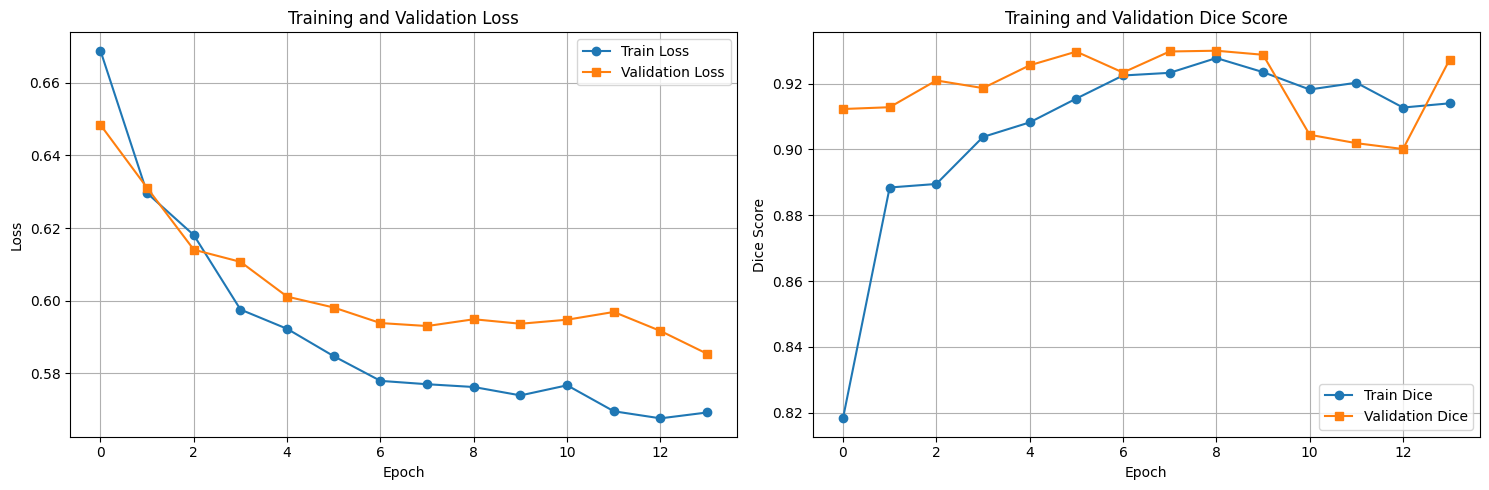

In [17]:
plot_training_history(history)

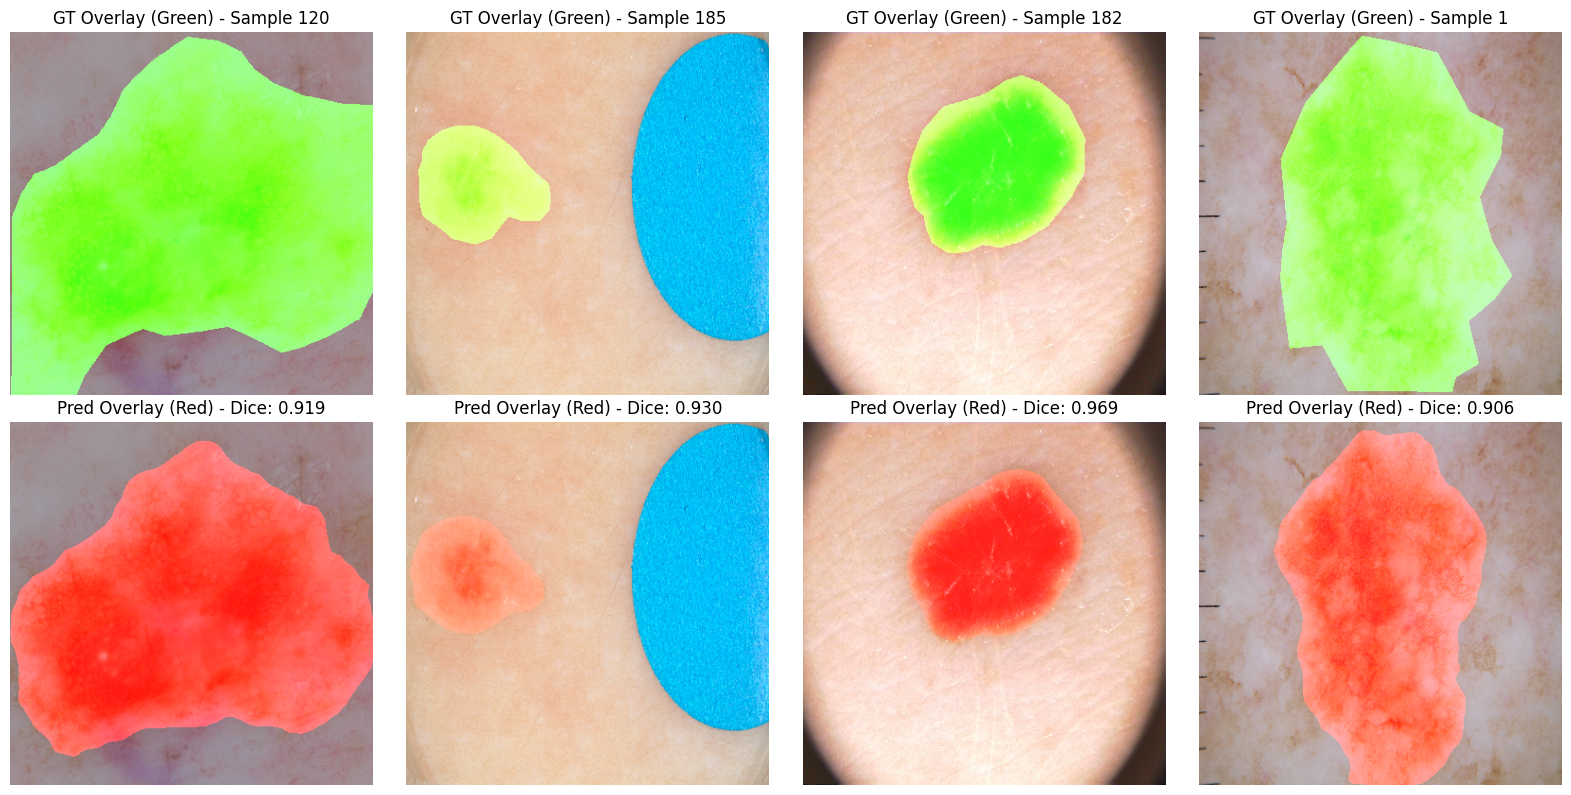

In [18]:
plot_overlay_predictions(model, val_dataset, num_samples=4)

# Post-processing

Note: thử dùng flip xem có cải thiện không (Không)

In [19]:
def multi_scale_inference(model, image, scales=[0.8, 1.0, 1.2]):
    """Multi-scale inference for better results"""
    device = next(model.parameters()).device
    model.eval()
    
    original_h, original_w = image.shape[:2]
    predictions = []
    
    with torch.no_grad():
        for scale in scales:
            # Resize image
            new_h, new_w = int(original_h * scale), int(original_w * scale)
            if scale != 1.0:
                scaled_image = cv2.resize(image, (new_w, new_h))
            else:
                scaled_image = image.copy()
            
            # Preprocess
            transform = A.Compose([
                A.Resize(384, 384),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            
            processed = transform(image=scaled_image)['image']
            tensor_image = torch.from_numpy(processed.transpose(2, 0, 1)).float()
            tensor_image = tensor_image.unsqueeze(0).to(device)
            
            # Predict
            y1, y2 = model(tensor_image)
            pred = torch.sigmoid(y2).detach().cpu().numpy()
        
            # Ensure shape [1, 1, H, W] -> [H, W]
            if pred.ndim == 4:
                pred = pred[0, 0]
            elif pred.ndim == 3:
                pred = pred[0]
            print(f"Pred shape at scale {scale}: {pred.shape}")
            
            # Resize back
            pred = cv2.resize(pred, (original_w, original_h))
                
            predictions.append(pred)

    
    # Average predictions
    final_pred = np.mean(predictions, axis=0)
    return final_pred

Sau khi in ra một số sample, e viết hàm này để xử lý một số trường hợp vẫn còn tồn đọng trong dataset:
- Các vùng tối nhỏ xung quanh vùng hắc tố chính
- Kết nối tạo thành vùng quá rộng so với dự đoán chính

Tuning region size and threshold to mark

In [20]:
def post_process_mask(mask, min_area=150):
    """Post-process predicted mask"""
    mask_binary = (mask > 0.6).astype(np.uint8)

    #Remove small noisy regions
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_binary = cv2.morphologyEx(mask_binary, cv2.MORPH_OPEN, kernel_small)
    
    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask_binary, connectivity=8
    )
    
    result = np.zeros_like(mask_binary)
    
    if num_labels > 1:
        # Keep largest component above threshold
        areas = stats[1:, cv2.CC_STAT_AREA]
        if len(areas) > 0:
            largest_label = np.argmax(areas) + 1
            if stats[largest_label, cv2.CC_STAT_AREA] >= min_area:
                result[labels == largest_label] = 1
    
    # Morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)
    # result = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel)
    
    return result

In [21]:
def mask_to_rle(mask):
    """Convert binary mask to RLE encoding"""
    pixels = mask.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(map(str, runs))

In [22]:
def predict_test_set(model_path, test_image_folder, output_csv='submission.csv'):
    """Generate predictions for test set"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load model
    model = DoubleUNet()
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Get test images
    test_images = sorted(glob.glob(os.path.join(test_image_folder, "*.jpg")))
    
    results = []
    
    for img_path in tqdm(test_images, desc="Predicting"):
        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # # Multi-scale inference
        pred = multi_scale_inference(model, image)
        
        # # Post-process
        pred_processed = post_process_mask(pred)
        
        # Convert to RLE
        rle = mask_to_rle(pred_processed)
        
        # Get image ID
        img_id = os.path.basename(img_path).replace('.jpg', '')
        
        results.append({'ID': img_id, 'Mask': rle})
    
    # Save results
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Predictions saved to {output_csv}")

In [23]:
predict_test_set(
        model_path='/kaggle/working/best_doubleunet_model.pth',
        test_image_folder=test_image_folder,
        output_csv='doubleunet_submission.csv'
)

Predicting:   1%|          | 1/192 [00:00<00:42,  4.47it/s]

Pred shape at scale 0.8: (384, 384)
Pred shape at scale 1.0: (384, 384)
Pred shape at scale 1.2: (384, 384)


Predicting:   1%|          | 2/192 [00:00<00:38,  4.90it/s]

Pred shape at scale 0.8: (384, 384)
Pred shape at scale 1.0: (384, 384)
Pred shape at scale 1.2: (384, 384)
Pred shape at scale 0.8: (384, 384)


Predicting:   2%|▏         | 3/192 [00:00<00:37,  5.03it/s]

...

Pred shape at scale 0.8: (384, 384)
Pred shape at scale 1.0: (384, 384)
Pred shape at scale 1.2: (384, 384)
Pred shape at scale 0.8: (384, 384)


Predicting:  99%|█████████▉| 191/192 [00:46<00:00,  4.11it/s]

Pred shape at scale 1.0: (384, 384)
Pred shape at scale 1.2: (384, 384)
Pred shape at scale 0.8: (384, 384)


Predicting: 100%|██████████| 192/192 [00:47<00:00,  4.08it/s]

Pred shape at scale 1.0: (384, 384)
Pred shape at scale 1.2: (384, 384)
Predictions saved to doubleunet_submission.csv


Kết quả cho thấy dice giao động tầm ~ 0.9 khi valid và với tập test là 0.89.

Sau khi nghiên cứu thêm, em thử một chút cải tiến như đổi backbone hiệu quả hơn, training thêm với dataset khác xem có cải thiện gì không. Kết quả cho thấy mô hình có cải thiện 1 chút khi đã nâng dice score lên 0.92 ở trên tập valid và 0.9 ở trên tập test. 

# More

In [ ]:
import shutil

In [ ]:
def combine_isic_dataset():
    # Source folders
    image_folders = [
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1-2_Training_Input/ISIC2018_Task1-2_Training_Input",
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1-2_Validation_Input/ISIC2018_Task1-2_Validation_Input", 
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1-2_Test_Input/ISIC2018_Task1-2_Test_Input",
        '/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Train/Image'
    ]
    
    mask_folders = [
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1_Training_GroundTruth/ISIC2018_Task1_Training_GroundTruth",
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1_Validation_GroundTruth/ISIC2018_Task1_Validation_GroundTruth",
        "/kaggle/input/isic2018-task1-dataset/ISIC2018_Task1_Test_GroundTruth/ISIC2018_Task1_Test_GroundTruth",
        '/kaggle/input/skin-lesion-segmentation-dataset/Dataset/Train/Mask'
    ]
    
    # Create output folders
    output_base = "combined_all_data"
    train_image_dir = f"{output_base}/Train/Image"
    train_mask_dir = f"{output_base}/Train/Mask"
    
    os.makedirs(train_image_dir, exist_ok=True)
    os.makedirs(train_mask_dir, exist_ok=True)
    
    total_images = 0
    total_masks = 0
    
    # Combine images
    print("Copying images...")
    for folder in image_folders:
        if os.path.exists(folder):
            images = glob.glob(f"{folder}/*.jpg") + glob.glob(f"{folder}/*.png")
            print(f"   {folder}: {len(images)} images")
            
            for img_path in tqdm(images, desc=f"Copying from {folder}"):
                img_name = os.path.basename(img_path)
                # Ensure .jpg extension
                if not img_name.lower().endswith('.jpg'):
                    img_name = img_name.rsplit('.', 1)[0] + '.jpg'
                
                dst_path = os.path.join(train_image_dir, img_name)
                shutil.copy2(img_path, dst_path)
                total_images += 1
        else:
            print(f"{folder} not found")
    
    # Combine masks  
    print("Copying masks...")
    for folder in mask_folders:
        if os.path.exists(folder):
            masks = glob.glob(f"{folder}/*.png") + glob.glob(f"{folder}/*.jpg")
            print(f"   {folder}: {len(masks)} masks")
            
            for mask_path in tqdm(masks, desc=f"Copying from {folder}"):
                mask_name = os.path.basename(mask_path)
                # Convert to .png and remove _segmentation suffix if exists
                base_name = mask_name.replace('_segmentation', '').rsplit('.', 1)[0]
                mask_name = base_name + '.png'
                
                dst_path = os.path.join(train_mask_dir, mask_name)
                shutil.copy2(mask_path, dst_path)
                total_masks += 1
        else:
            print(f"{folder} not found")
    
    print(f"\nDataset combination complete!")
    print(f"   Total images: {total_images}")
    print(f"   Total masks: {total_masks}")
    print(f"   Output: {output_base}/Train/")
    
    # # Verify matching pairs
    # verify_dataset_pairs(train_image_dir, train_mask_dir)
    
    return total_images, total_masks

In [ ]:
combine_isic_dataset()

Thêm một số cải tiến về mặt chi tiết:
Nhưng đều không hiệu quả (thêm hàm loss, thêm augmentation, ....)